In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
llms = ["gpt-4o", "gpt-4o-mini", "Meta-Llama-3.1-8B-Instruct", "Meta-Llama-3.1-70B-Instruct"]
llm_names = ["GPT-4o", "GPT-4o Mini", "Llama 3.1 8B", "Llama 3.1 70B"]
folder = "data/programs"

In [3]:
runtime_results = []

for llm in llms:
    df = pd.read_csv(f"{folder}/{llm}_runtime_abscon_10.csv")
    df["llm"] = llm
    runtime_results.append(df)

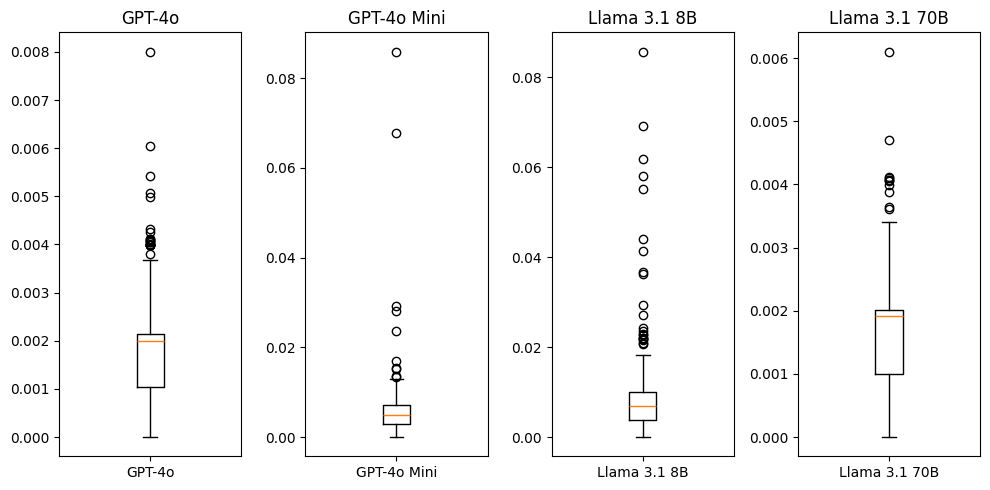

In [4]:
# plot problem_build_runtimes as boxplot for each llm as subfigures
fig, axes = plt.subplots(1, 4, figsize=(10, 5), sharey=False)

for i, (llm, df) in enumerate(zip(llm_names, runtime_results)):
    ax = axes[i]
    ax.boxplot(df["problem_build_runtimes"], tick_labels=[llm])
    ax.set_title(llm)
plt.tight_layout()
plt.show()

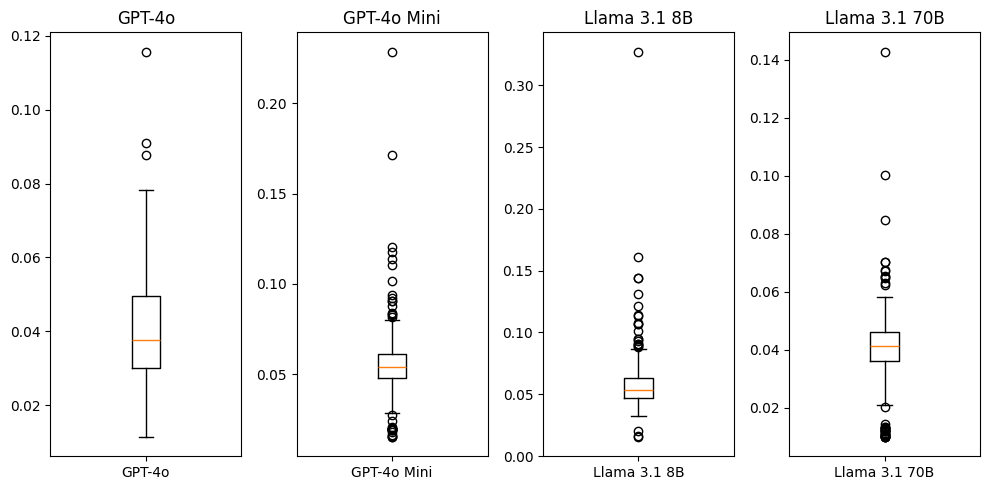

In [5]:
# plot problem_solve_runtimes as boxplot for each llm as subfigures
fig, axes = plt.subplots(1, 4, figsize=(10, 5), sharey=False)

for i, (llm, df) in enumerate(zip(llm_names, runtime_results)):
    ax = axes[i]
    ax.boxplot(df["problem_solve_runtimes"], tick_labels=[llm])
    ax.set_title(llm)
plt.tight_layout()
plt.show()

In [6]:
# show the average problem_build_runtimes for each llm  +- std
for i, (llm, df) in enumerate(zip(llm_names, runtime_results)):
    print(f"{llm}: {df['problem_build_runtimes'].mean():.2f} +- {df['problem_build_runtimes'].std():.2f}")

GPT-4o: 0.00 +- 0.00
GPT-4o Mini: 0.01 +- 0.01
Llama 3.1 8B: 0.01 +- 0.01
Llama 3.1 70B: 0.00 +- 0.00


In [7]:
# show the average problem_solve_runtimes for each llm  +- std
for i, (llm, df) in enumerate(zip(llm_names, runtime_results)):
    print(f"{llm}: {df['problem_solve_runtimes'].mean():.2f} +- {df['problem_solve_runtimes'].std():.2f}")

GPT-4o: 0.04 +- 0.02
GPT-4o Mini: 0.06 +- 0.02
Llama 3.1 8B: 0.06 +- 0.02
Llama 3.1 70B: 0.04 +- 0.01


In [8]:
# show the average embedding_runtime for each llm  +- std
for i, (llm, df) in enumerate(zip(llm_names, runtime_results)):
    runtime = runtime_results[i]["embedding_runtime"].apply(lambda x: sum(eval(x)))
    print(f"{llm}: {runtime.mean():.2f} +- {runtime.std():.2f}")

GPT-4o: 0.36 +- 0.09
GPT-4o Mini: 0.48 +- 0.14
Llama 3.1 8B: 0.52 +- 0.15
Llama 3.1 70B: 0.38 +- 0.12


In [9]:
# show the average graph_matching_runtime for each llm  +- std
for i, (llm, df) in enumerate(zip(llm_names, runtime_results)):
    runtime = runtime_results[i]["graph_matching_runtime"].apply(lambda x: sum(eval(x)))
    print(f"{llm}: {runtime.mean():.2f} +- {runtime.std():.2f}")

GPT-4o: 0.46 +- 2.28
GPT-4o Mini: 1.28 +- 5.08
Llama 3.1 8B: 4.78 +- 9.69
Llama 3.1 70B: 0.50 +- 1.97


## Check the relation between entropy and runtime

In [10]:
import pickle

In [27]:
llm_name = "Meta-Llama-3.1-70B-Instruct"
filename = f"{folder}/{llm_name}_partial_models_10.pkl"

with open(filename, "rb") as f:
    partial_models = pickle.load(f)

num_candidates = 10

In [28]:
# convert the partial model weight to probability
for partial_model in partial_models:
    for node, data in partial_model.nodes(data=True):
        if "weight" in data:
            data["weight"] = data["weight"] / num_candidates
    for u, v, data in partial_model.edges(data=True):
        if "weight" in data:
            data["weight"] = data["weight"] / num_candidates

In [29]:
# calculate the entropy for each partial model
import numpy as np
entropies = []
for partial_model in partial_models:
    node_weights = np.array([data["weight"] for _, data in partial_model.nodes(data=True) if "weight" in data])
    edge_weights = np.array([data["weight"] for _, _, data in partial_model.edges(data=True) if "weight" in data])
    weights = np.concatenate((node_weights, edge_weights))

    if len(weights) > 0:
        # Each weight corresponds to a probability of a binary event
        # Adding a small constant to avoid log(0)
        entropy = (-np.sum(weights * np.log2(weights + 1e-10)) - np.sum((1 - weights) * np.log2(1 - weights + 1e-10)))
        entropies.append(entropy)

In [30]:
idx = llms.index(llm_name)
embedding_runtimes = runtime_results[idx]["embedding_runtime"].apply(lambda x: sum(eval(x)))
graph_matching_runtime = runtime_results[idx]["graph_matching_runtime"].apply(lambda x: sum(eval(x)))
problem_build_runtimes = runtime_results[idx]["problem_build_runtimes"]
problem_solve_runtimes = runtime_results[idx]["problem_solve_runtimes"]

# add all runtime together
total_runtimes = embedding_runtimes + graph_matching_runtime + problem_build_runtimes + problem_solve_runtimes


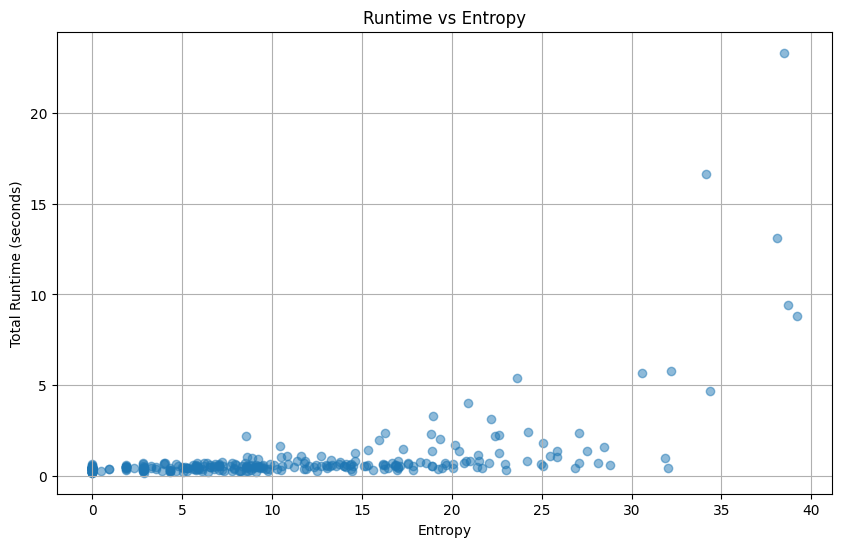

In [31]:
# Plot the runtime vs entropy as a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(entropies, total_runtimes, alpha=0.5)
plt.title("Runtime vs Entropy")
plt.xlabel("Entropy")
# plt.ylim(0, 5)
plt.ylabel("Total Runtime (seconds)")
plt.grid(True)
plt.show()

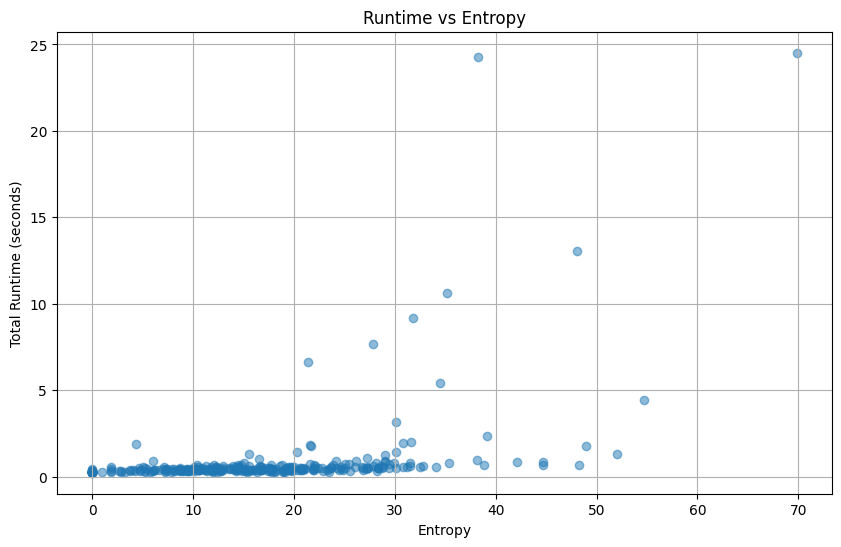

In [20]:
# Plot the runtime vs entropy as a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(entropies, total_runtimes, alpha=0.5)
plt.title("Runtime vs Entropy")
plt.xlabel("Entropy")
plt.ylabel("Total Runtime (seconds)")
plt.grid(True)
plt.show()

In [21]:
# only include entropy smaller than 13
filtered_entropies =[]
filtered_runtimes = []
for entropy, runtime in zip(entropies, total_runtimes):
    if entropy < 10:
        filtered_entropies.append(entropy)
        filtered_runtimes.append(runtime)

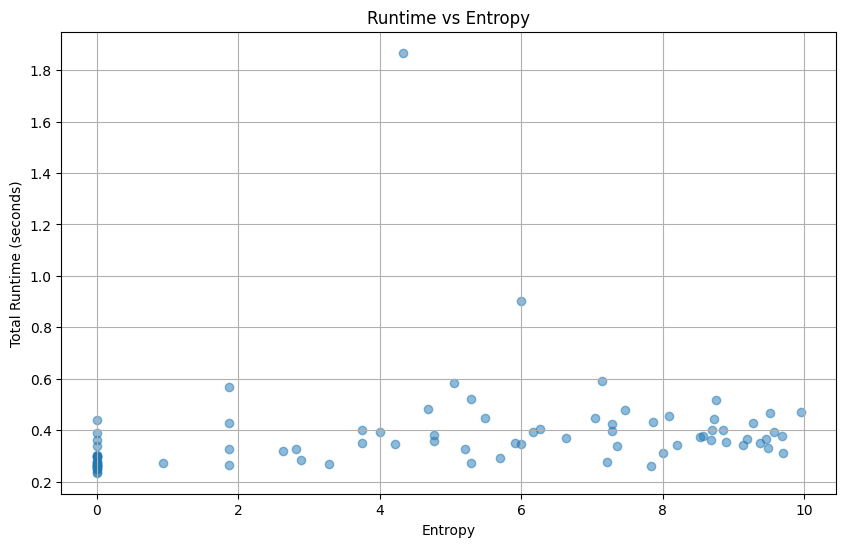

In [22]:
# Plot the runtime vs entropy as a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(filtered_entropies, filtered_runtimes, alpha=0.5)
plt.title("Runtime vs Entropy")
plt.xlabel("Entropy")
plt.ylabel("Total Runtime (seconds)")
plt.grid(True)
plt.show()

In [21]:
# Check the correlation between entropy and runtime
from scipy.stats import pearsonr, spearmanr
pearson_corr, pearson_p = pearsonr(entropies, total_runtimes)
spearman_corr, spearman_p = spearmanr(entropies, total_runtimes)
print(f"Pearson correlation: {pearson_corr:.4f} (p-value: {pearson_p:.4f})")
print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_p:.4f})")

Pearson correlation: 0.2745 (p-value: 0.0000)
Spearman correlation: 0.5366 (p-value: 0.0000)
